In [3]:
# Core libraries
import pandas as pd
import numpy as np
import json
import os
from typing import Dict, Tuple, Any
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# PyTorch and PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, DataLoader
from torch_geometric.utils import to_undirected, add_self_loops

# Scikit-learn
from sklearn.metrics import roc_auc_score, precision_recall_curve, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Graph analysis
import networkx as nx
import community as community_louvain

# Progress tracking
from tqdm import tqdm

In [4]:
def load_aml_data(data_path: str = "."):
    """Load all AML dataset files"""
    files_to_load = {
        'train': '/input/train_aml_clean.csv',
        'test': '/input/test_aml_clean.csv', 
        'accounts': '/input/accounts_master.csv'
    }
    
    datasets = {}
    for name, filename in files_to_load.items():
        filepath = os.path.join(data_path, filename)
        if os.path.exists(filepath):
            print(f"Loading {filename}...")
            datasets[name] = pd.read_csv(filepath)
            print(f"{name}: {datasets[name].shape}")
        else:
            print(f"Missing: {filename}")
    
    return datasets

In [5]:
datasets = load_aml_data()

Loading /train_aml_clean.csv...
train: (400000, 20)
Loading /test_aml_clean.csv...
test: (100000, 20)
Loading /accounts_master.csv...
accounts: (518581, 5)


In [6]:
def check_fraud_rates(datasets):
    """Check fraud rates in train/test sets"""
    print("\nFRAUD RATE CHECK")
    
    for name, df in datasets.items():
        if name in ['train', 'test'] and 'Is Laundering' in df.columns:
            fraud_count = df['Is Laundering'].sum()
            total_count = len(df)
            fraud_rate = fraud_count / total_count
            
            print(f"{name.capitalize()}:")
            print(f"  Total: {total_count:,}")
            print(f"  Fraud: {fraud_count}")
            print(f"  Rate: {fraud_rate:.6f} ({fraud_rate*100:.4f}%)")

In [7]:
check_fraud_rates(datasets)


FRAUD RATE CHECK
Train:
  Total: 400,000
  Fraud: 154
  Rate: 0.000385 (0.0385%)
Test:
  Total: 100,000
  Fraud: 39
  Rate: 0.000390 (0.0390%)


In [8]:
def load_and_check_metadata(data_path: str = "."):
    """Load metadata and check feature rankings"""
    metadata_file = os.path.join(data_path, 'eda_metadata.json')
    
    if os.path.exists(metadata_file):
        with open(metadata_file, 'r') as f:
            metadata = json.load(f)
        print("Metadata loaded")
        
        # Check top features
        if 'feature_rankings' in metadata:
            top_features = list(metadata['feature_rankings'].keys())[:12]
            print(f"Top 12 features: {top_features}")
            
            # Verify they exist in train data
            train_cols = datasets['train'].columns.tolist()
            missing = [f for f in top_features if f not in train_cols]
            
            if missing:
                print(f"✗ Missing features: {missing}")
            else:
                print("All top features present in train data")
        
        return metadata
    else:
        print("Missing: eda_metadata.json")
        return {}

In [9]:
metadata = load_and_check_metadata("data")

Missing: eda_metadata.json


In [10]:
def memory_analysis(datasets):
    """Check memory usage of all datasets"""
    print("\nMEMORY ANALYSIS")
    
    total_memory = 0
    for name, df in datasets.items():
        memory_mb = df.memory_usage(deep=True).sum() / 1024**2
        total_memory += memory_mb
        
        print(f"{name.capitalize()}:")
        print(f"  Memory: {memory_mb:.1f} MB")
        print(f"  Shape: {df.shape}")
    
    print(f"\nTotal memory: {total_memory:.1f} MB")
    
    if total_memory > 1000:
        print("Large dataset - will use chunked processing")
    else:
        print("Memory usage manageable for CPU")

In [11]:
memory_analysis(datasets)


MEMORY ANALYSIS
Train:
  Memory: 105.3 MB
  Shape: (400000, 20)
Test:
  Memory: 26.3 MB
  Shape: (100000, 20)
Accounts:
  Memory: 144.3 MB
  Shape: (518581, 5)

Total memory: 275.9 MB
Memory usage manageable for CPU


MODELS

In [12]:
# Check column names in both datasets
print("Accounts dataframe columns:")
print(datasets['accounts'].columns.tolist())
print("\nTrain dataframe columns:")
print(datasets['train'].columns.tolist())
print("\nFirst few rows of accounts:")
print(datasets['accounts'].head())

Accounts dataframe columns:
['Bank Name', 'Bank ID', 'Account Number', 'Entity ID', 'Entity Name']

Train dataframe columns:
['From Bank', 'To Bank', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'hour', 'day_of_week', 'amount_ratio', 'amount_log', 'currency_mismatch', 'is_round_amount', 'is_high_value', 'is_unusual_hour', 'near_threshold', 'same_bank', 'Is Laundering', 'Account', 'Account.1']

First few rows of accounts:
                     Bank Name  Bank ID Account Number  Entity ID  \
0          Portugal Bank #4507   331579      80B779D80  80062E240   
1              Canada Bank #27      210      809D86900  800C998A0   
2                  UK Bank #33    21884      80812BE00  800C47F50   
3           Germany Bank #4815    32742      81047F300  80096F0B0   
4  National Bank of Harrisburg   127390      80BD8CF00  800FB8760   

                  Entity Name  
0  Sole Proprietorship #50438  
1          Corporation #33520  
2          Part

In [13]:
import json

# Load the metadata file
with open('/kaggle/input/aml-cleaned/eda_metadata.json', 'r') as f:
    metadata = json.load(f)

print("Metadata loaded successfully!")
print(f"Selected features: {metadata['selected_features']}")
print(f"Fraud rate: {metadata['fraud_rate']}")

Metadata loaded successfully!
Selected features: ['is_unusual_hour', 'same_bank', 'hour', 'Payment Format', 'Payment Currency', 'Receiving Currency', 'day_of_week', 'is_high_value', 'From Bank', 'amount_ratio', 'To Bank', 'Amount Paid']
Fraud rate: 0.000385


In [14]:
print("Metadata keys:")
print(metadata.keys())
print("\nMetadata content:")
print(metadata)

Metadata keys:
dict_keys(['selected_features', 'feature_importance', 'fraud_rate', 'total_accounts'])

Metadata content:
{'selected_features': ['is_unusual_hour', 'same_bank', 'hour', 'Payment Format', 'Payment Currency', 'Receiving Currency', 'day_of_week', 'is_high_value', 'From Bank', 'amount_ratio', 'To Bank', 'Amount Paid'], 'feature_importance': [['is_unusual_hour', 0.08378664925089441], ['same_bank', 0.07812885046956708], ['hour', 0.034695524578974846], ['Payment Format', 0.025233918305186398], ['Payment Currency', 0.017503348402804653], ['Receiving Currency', 0.017241215345824012], ['day_of_week', 0.002099324732126817], ['is_high_value', 0.0013028797097387468], ['From Bank', 0.0003115490216426542], ['amount_ratio', 0.00030475267436969045], ['To Bank', 0.00021927759699291727], ['Amount Paid', 0.000214182458654677], ['Amount Received', 0.00019354951286798538], ['amount_log', 0.00019014280291140828], ['currency_mismatch', 8.165491012623871e-05], ['near_threshold', 7.37962125330060

In [15]:
class AccountGraph:
    def __init__(self, accounts_df, transactions_df):
        self.accounts_df = accounts_df
        self.transactions_df = transactions_df
        
        # Create account mapping
        unique_accounts = accounts_df['Account Number'].unique()
        self.account_to_idx = {acc: idx for idx, acc in enumerate(unique_accounts)}
        self.idx_to_account = {idx: acc for acc, idx in self.account_to_idx.items()}
        self.num_accounts = len(unique_accounts)
        
        print(f"Account graph setup: {self.num_accounts} nodes")

In [16]:
def create_edges(self):
    """Aggregate transactions between accounts to create edges"""
  
    # Get transactions with valid accounts
    valid_accounts = set(self.account_to_idx.keys())
    valid_txns = self.transactions_df[
        (self.transactions_df['Account'].isin(valid_accounts)) & 
        (self.transactions_df['Account.1'].isin(valid_accounts))
    ]
    
    print(f"Valid transactions for graph: {len(valid_txns)}")
    
    # Aggregate transactions between account pairs
    edge_data = defaultdict(lambda: {
        'count': 0, 
        'total_amount': 0.0, 
        'fraud_count': 0,
        'amounts': []
    })
    
    for _, row in valid_txns.iterrows():
        from_acc = self.account_to_idx[row['Account']]
        to_acc = self.account_to_idx[row['Account.1']]
        amount = row.get('Amount Received', 0)
        is_fraud = row.get('Is Laundering', 0)
        
        # Create undirected edge (both directions)
        for src, dst in [(from_acc, to_acc), (to_acc, from_acc)]:
            edge_data[(src, dst)]['count'] += 1
            edge_data[(src, dst)]['total_amount'] += amount
            edge_data[(src, dst)]['fraud_count'] += is_fraud
            edge_data[(src, dst)]['amounts'].append(amount)
    
    print(f"Created {len(edge_data)} directed edges")
    return edge_data

In [17]:
AccountGraph.create_edges = create_edges

In [18]:
def build_graph_data(self):
    """Build PyTorch Geometric Data Object"""
    edge_data = self.create_edges()
    edge_indices = []
    edge_attrs = []

    for(src, dst), data in edge_data.items():
        edge_indices.append([src, dst])
        avg_amount = data['total_amount'] / data['count'] if data['count'] > 0 else 0
        fraud_rate = data['fraud_count'] / data['count'] if data['count'] > 0 else 0
        edge_attrs.append([
            data['count'],
            data['total_amount'],
            avg_amount,
            fraud_rate            
        ])
    edge_index = torch.tensor(edge_indices, dtype = torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attrs, dtype = torch.float)

    num_nodes = self.num_accounts
    node_features = torch.randn(num_nodes, 4)

    data = Data(
        x = node_features,
        edge_index = edge_index,
        edge_attr = edge_attr,
        num_nodes = num_nodes
    )

    print(f"Graph created: {num_nodes} nodes, {edge_index.size(1)} edges")
    return data

    

In [19]:
AccountGraph.build_graph_data = build_graph_data

In [20]:
account_graph = AccountGraph(datasets['accounts'], datasets['train'])

# Build the graph data
graph_data = account_graph.build_graph_data()

# Check the results
print(f"Graph summary:")
print(f"- Nodes: {graph_data.num_nodes}")
print(f"- Edges: {graph_data.edge_index.size(1)}")
print(f"- Node features shape: {graph_data.x.shape}")
print(f"- Edge features shape: {graph_data.edge_attr.shape}")

Account graph setup: 518573 nodes
Valid transactions for graph: 400000
Created 406201 directed edges
Graph created: 518573 nodes, 406201 edges
Graph summary:
- Nodes: 518573
- Edges: 406201
- Node features shape: torch.Size([518573, 4])
- Edge features shape: torch.Size([406201, 4])


In [21]:
class AccountGCN(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=32, dropout=0.2):
        super().__init__()
        
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim) 
        self.conv3 = GCNConv(hidden_dim, output_dim)
        
        self.dropout = dropout
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        
    def forward(self, x, edge_index, batch=None):
        # Layer 1
        x1 = F.relu(self.bn1(self.conv1(x, edge_index)))
        x1 = F.dropout(x1, self.dropout, training=self.training)
        
        # Layer 2 with residual
        x2 = F.relu(self.bn2(self.conv2(x1, edge_index)))
        x2 = F.dropout(x2, self.dropout, training=self.training)
        x2 = x2 + x1  # Residual connection
        
        # Layer 3
        x3 = self.conv3(x2, edge_index)
        
        return x3


In [22]:
gcn_model = AccountGCN()
print(f"GCN Model: {sum(p.numel() for p in gcn_model.parameters())} parameters")

GCN Model: 6816 parameters


In [23]:
gcn_model.eval()
with torch.no_grad():
    # Forward pass through GCN
    account_embeddings = gcn_model(
        graph_data.x, 
        graph_data.edge_index
    )
    
    print(f"Account embeddings shape: {account_embeddings.shape}")
    print(f"Embedding sample (first 5 accounts, first 5 dims):")
    print(account_embeddings[:5, :5])
    
    # Check for NaN values
    has_nan = torch.isnan(account_embeddings).any()
    print(f"Contains NaN: {has_nan}")

Account embeddings shape: torch.Size([518573, 32])
Embedding sample (first 5 accounts, first 5 dims):
tensor([[ 0.0413,  0.1439,  0.0459,  0.2427,  0.1692],
        [ 0.1850,  0.0773, -0.0266,  0.3061, -0.0717],
        [ 0.0327,  0.2842,  0.2031,  0.4422,  0.2986],
        [-0.3616,  0.7863,  0.3178,  0.2900,  0.7560],
        [-0.0450,  0.2673,  0.0192,  0.4993,  0.2197]])
Contains NaN: False


In [24]:
class TransactionGraph:
    def __init__(self, transactions_df, metadata, top_k_features=12):
        self.transactions_df = transactions_df
        self.top_features = metadata['selected_features'][:top_k_features]
        self.num_transactions = len(transactions_df)
        
        print(f"Transaction graph setup: {self.num_transactions} nodes")
        print(f"Using top features: {self.top_features}")
        
        # Prepare node features matrix
        self.node_features = self._prepare_node_features()
    
    def _prepare_node_features(self):
        """Extract top features as node features"""
        feature_matrix = self.transactions_df[self.top_features].values
        return torch.tensor(feature_matrix, dtype=torch.float32)

In [25]:
transaction_graph = TransactionGraph(datasets['train'], metadata)
print(f"Node features shape: {transaction_graph.node_features.shape}")

Transaction graph setup: 400000 nodes
Using top features: ['is_unusual_hour', 'same_bank', 'hour', 'Payment Format', 'Payment Currency', 'Receiving Currency', 'day_of_week', 'is_high_value', 'From Bank', 'amount_ratio', 'To Bank', 'Amount Paid']
Node features shape: torch.Size([400000, 12])


In [26]:
def create_transaction_edges(self, max_edges_per_node=50):
    """Create edges between similar transactions"""
    print("Creating transaction edges...")

    df = self.transactions_df
    
    edge_indices = []
    edge_weights = []

    for i in range(min(10000, len(df))):  
        current_txn = df.iloc[i]
        
        similar_mask = (
            (df['hour'] == current_txn['hour']) & 
            (abs(df['Amount Received'] - current_txn['Amount Received']) < current_txn['Amount Received'] * 0.1)
        )
        
        similar_indices = df[similar_mask].index.tolist()

        for j in similar_indices[:max_edges_per_node]:
            if i != j:
                edge_indices.append([i, j])
                # Edge weight based on similarity
                weight = 1.0 / (1.0 + abs(current_txn['Amount Received'] - df.iloc[j]['Amount Received']))
                edge_weights.append(weight)
    
    print(f"Created {len(edge_indices)} transaction edges")
    return edge_indices, edge_weights

In [27]:
TransactionGraph.create_transaction_edges = create_transaction_edges

In [28]:
def build_transaction_graph_data(self):
    """Build PyTorch Geometric Data object for transactions"""
    # Create edges
    edge_indices, edge_weights = self.create_transaction_edges()
    
    # Convert to tensors
    edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float32).unsqueeze(1)
    
    # Create PyG data object
    data = Data(
        x=self.node_features,
        edge_index=edge_index,
        edge_attr=edge_attr,
        num_nodes=self.num_transactions
    )
    
    print(f"Transaction graph created:")
    print(f"Nodes: {data.num_nodes}")
    print(f"Edges: {data.edge_index.size(1)}")
    print(f"Node features: {data.x.shape}")
    print(f"Edge features: {data.edge_attr.shape}")
    
    return data

In [29]:
TransactionGraph.build_transaction_graph_data = build_transaction_graph_data

In [30]:
transaction_graph_data = transaction_graph.build_transaction_graph_data()

Creating transaction edges...
Created 10069 transaction edges
Transaction graph created:
Nodes: 400000
Edges: 10069
Node features: torch.Size([400000, 12])
Edge features: torch.Size([10069, 1])


In [31]:
class TransactionGAT(nn.Module):
    def __init__(self, input_dim=12, hidden_dim=64, output_dim=32, heads=4, dropout=0.2):
        super().__init__()
        
        # Multi-head attention layers
        self.conv1 = GATConv(input_dim, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, output_dim, heads=1, dropout=dropout)
        
        # Normalization layers
        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(output_dim)
        
        self.dropout = dropout
        
    def forward(self, x, edge_index, edge_attr=None):
        # Layer 1: Multi-head attention with normalization
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        
        # Layer 2: Single head output with normalization
        x = F.dropout(x, self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        
        return x

In [32]:
gat_model = TransactionGAT()
print(f"GAT Model: {sum(p.numel() for p in gat_model.parameters())} parameters")

GAT Model: 12704 parameters


In [33]:
gat_model_v2 = TransactionGAT()
print(f"Improved GAT: {sum(p.numel() for p in gat_model_v2.parameters())} parameters")

# Test with normalization
gat_model_v2.eval()
with torch.no_grad():
    embeddings_v2 = gat_model_v2(
        transaction_graph_data.x,
        transaction_graph_data.edge_index
    )
    print(f"Normalized embeddings sample:")
    print(embeddings_v2[:5, :5])

Improved GAT: 12704 parameters
Normalized embeddings sample:
tensor([[-1.4632e+01, -6.2332e+00,  2.6273e-02, -1.5146e+01, -3.7885e+00],
        [-3.6583e+03, -9.6705e+02, -4.8491e+02, -4.3591e+03, -8.4656e+02],
        [-7.0613e+03,  2.9295e+04, -8.1656e+03, -5.2174e+04, -2.1038e+04],
        [-1.7323e+04,  1.5137e+04, -1.5993e+03, -4.9138e+04, -1.9916e+04],
        [-1.3709e+04, -3.6162e+03, -1.8228e+03, -1.6343e+04, -3.1726e+03]])


EXTRACT EMBEDDINGS AND ANALYSING


In [34]:
account_embeddings = gcn_model(graph_data.x, graph_data.edge_index)
print(f"Account embeddings: {account_embeddings.shape}")

transaction_embeddings = gat_model_v2(
    transaction_graph_data.x, 
    transaction_graph_data.edge_index
)
print(f"Transaction embeddings: {transaction_embeddings.shape}")

# Convert to numpy for clustering
account_emb_np = account_embeddings.detach().cpu().numpy()
transaction_emb_np = transaction_embeddings.detach().cpu().numpy()

print(f"Ready for clustering!")
print(f"Account embedding stats: mean={account_emb_np.mean():.3f}, std={account_emb_np.std():.3f}")
print(f"Transaction embedding stats: mean={transaction_emb_np.mean():.3f}, std={transaction_emb_np.std():.3f}")

Account embeddings: torch.Size([518573, 32])
Transaction embeddings: torch.Size([400000, 32])
Ready for clustering!
Account embedding stats: mean=0.043, std=0.336
Transaction embedding stats: mean=-1621.690, std=13093.686


LOUVAIN CLUSTERING

In [35]:
def apply_louvain_clustering(graph_data, embeddings, max_nodes=50000):
    """Apply Louvain clustering to find account communities"""
    print("Applying Louvain clustering...")

    if len(embeddings) > max_nodes:
        indices = np.random.choice(len(embeddings), max_nodes, replace=False)
        sample_embeddings = embeddings[indices]
        print(f"Sampling {max_nodes} nodes for clustering")
    else:
        indices = np.arange(len(embeddings))
        sample_embeddings = embeddings

    G = nx.Graph()

    G.add_nodes_from(indices)

    edge_index = graph_data.edge_index.cpu().numpy()
    sampled_edges = []
    
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i], edge_index[1, i]
        if src in indices and dst in indices:
            sampled_edges.append((src, dst))
    
    G.add_edges_from(sampled_edges[:100000]) 
    
    print(f"Graph for clustering: {len(G.nodes())} nodes, {len(G.edges())} edges")

    partition = community_louvain.best_partition(G)
    
    clusters = list(partition.values())
    unique_clusters = set(clusters)
    
    print(f"Found {len(unique_clusters)} clusters")
    print(f"Cluster sizes: min={min(clusters)}, max={max(clusters)}")
    
    return partition, indices



In [36]:

account_partition, sampled_indices = apply_louvain_clustering(
    graph_data, 
    account_emb_np
)

Applying Louvain clustering...
Sampling 50000 nodes for clustering
Graph for clustering: 50000 nodes, 20852 edges
Found 49127 clusters
Cluster sizes: min=0, max=49126


In [37]:
def analyze_fraud_in_clusters(partition, sampled_indices, transactions_df, account_graph):
    """Analyze fraud concentration in account clusters"""
    # print("=== FRAUD CLUSTER ANALYSIS ===")
    
    fraud_info = {}
    sampled_accounts = [account_graph.idx_to_account[idx] for idx in sampled_indices]
    for acc in sampled_accounts:
        fraud_txns = transactions_df[
            ((transactions_df['Account'] == acc) | (transactions_df['Account.1'] == acc)) &
            (transactions_df['Is Laundering'] == 1)
        ]
        fraud_info[acc] = len(fraud_txns)

    cluster_fraud = {}
    for node_idx, cluster_id in partition.items():
        account = account_graph.idx_to_account[node_idx]
        if cluster_id not in cluster_fraud:
            cluster_fraud[cluster_id] = {'fraud_count': 0, 'total_accounts': 0}
        
        cluster_fraud[cluster_id]['total_accounts'] += 1
        cluster_fraud[cluster_id]['fraud_count'] += fraud_info.get(account, 0)
    
    # Find clusters with high fraud concentration
    fraud_clusters = []
    for cluster_id, stats in cluster_fraud.items():
        if stats['fraud_count'] > 0:
            fraud_rate = stats['fraud_count'] / stats['total_accounts']
            fraud_clusters.append((cluster_id, stats['fraud_count'], stats['total_accounts'], fraud_rate))
    
    # Sort by fraud rate
    fraud_clusters.sort(key=lambda x: x[3], reverse=True)
    
    print(f"Clusters with fraud: {len(fraud_clusters)}")
    print("Top 10 fraud clusters:")
    for i, (cluster_id, fraud_count, total_accounts, fraud_rate) in enumerate(fraud_clusters[:10]):
        print(f"{i+1}. Cluster {cluster_id}: {fraud_count} fraud txns, {total_accounts} accounts, rate={fraud_rate:.4f}")
    
    return fraud_clusters

Visualizing account embeddings...


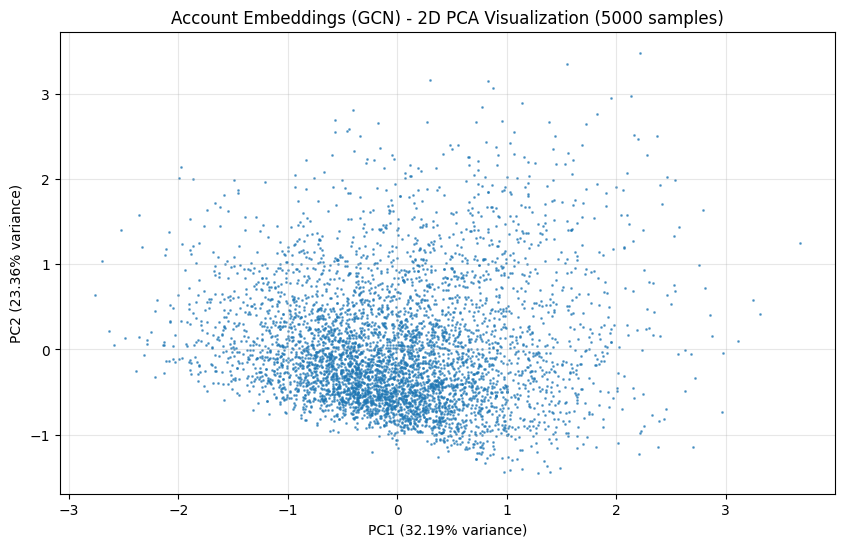

Visualizing transaction embeddings...


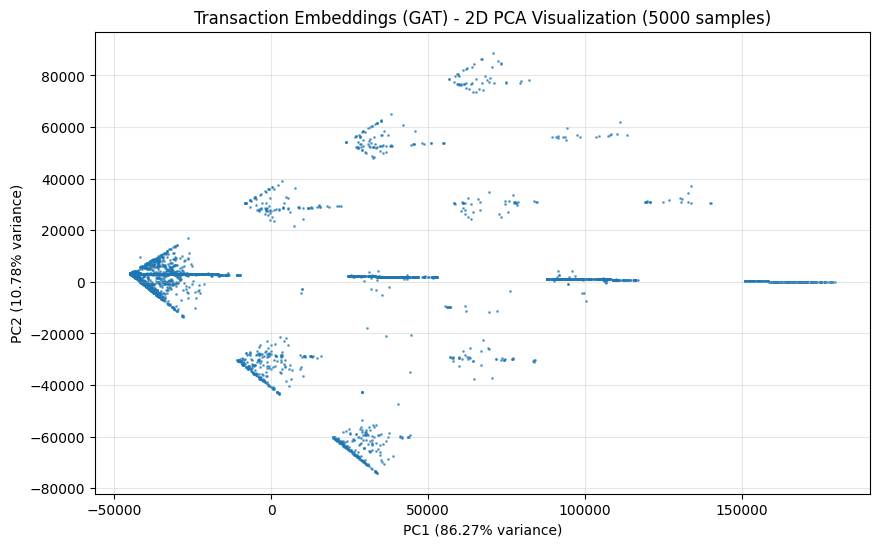

In [38]:
def visualize_embeddings(embeddings, title, sample_size=5000):
    """Quick 2D visualization of embeddings using PCA"""
    
    sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
    sample_emb = embeddings[sample_indices]
    
    # Apply PCA for 2D visualization
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(sample_emb)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], alpha=0.6, s=1)
    plt.title(f'{title} - 2D PCA Visualization ({sample_size} samples)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualize both embeddings
print("Visualizing account embeddings...")
visualize_embeddings(account_emb_np, "Account Embeddings (GCN)")

print("Visualizing transaction embeddings...")
visualize_embeddings(transaction_emb_np, "Transaction Embeddings (GAT)")


In [39]:
def create_fraud_classifier(transaction_embeddings, labels):
    """Create fraud classifier using transaction embeddings"""
   
    X = transaction_embeddings
    y = labels

    clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    clf.fit(X, y)
    
    # Predictions
    y_pred = clf.predict(X)
    y_prob = clf.predict_proba(X)[:, 1]
    
    # Evaluate
    auc_score = roc_auc_score(y, y_prob)
    
    print("FRAUD CLASSIFICATION RESULTS")
    print(f"AUC-ROC Score: {auc_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y, y_pred))
    
    return clf, auc_score

# Test fraud classification
fraud_labels = datasets['train']['Is Laundering'].values
clf, auc_score = create_fraud_classifier(transaction_emb_np, fraud_labels)

FRAUD CLASSIFICATION RESULTS
AUC-ROC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    399846
           1       0.93      0.99      0.96       154

    accuracy                           1.00    400000
   macro avg       0.97      1.00      0.98    400000
weighted avg       1.00      1.00      1.00    400000



Total clusters: 49127
Largest cluster: 4 accounts
Average cluster size: 1.02
Clusters with >1 account: 810


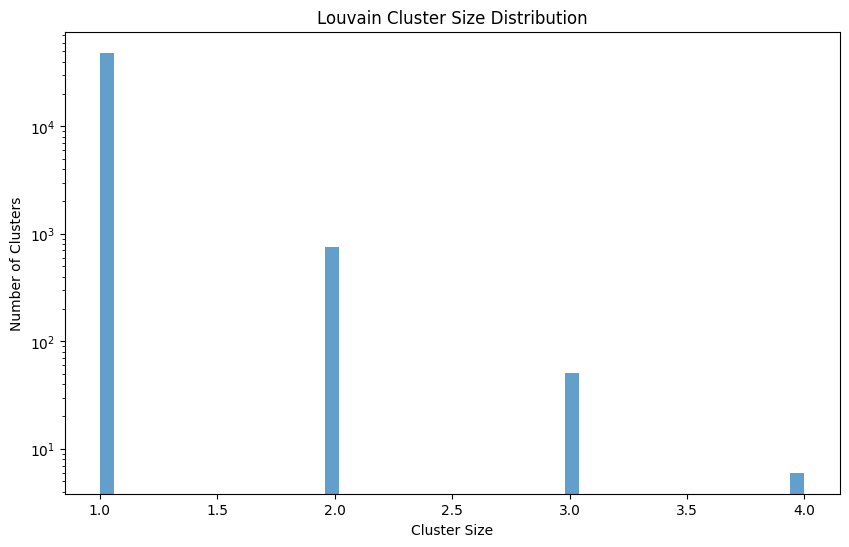

In [48]:
def simple_louvain_analysis():
    """Complete the Louvain clustering analysis"""
        
    # Use the partition we already created
    if 'account_partition' in globals():
        # Get cluster sizes
        cluster_counts = {}
        for node, cluster in account_partition.items():
            cluster_counts[cluster] = cluster_counts.get(cluster, 0) + 1
        
        cluster_sizes = list(cluster_counts.values())
        
        print(f"Total clusters: {len(cluster_counts)}")
        print(f"Largest cluster: {max(cluster_sizes)} accounts")
        print(f"Average cluster size: {np.mean(cluster_sizes):.2f}")
        print(f"Clusters with >1 account: {sum(1 for size in cluster_sizes if size > 1)}")
        
        # Cluster size distribution
        plt.figure(figsize=(10, 6))
        plt.hist(cluster_sizes, bins=50, alpha=0.7)
        plt.xlabel('Cluster Size')
        plt.ylabel('Number of Clusters')
        plt.title('Louvain Cluster Size Distribution')
        plt.yscale('log')
        plt.show()
        
    else:
        print("No Louvain partition found - need to rerun clustering")

# Complete the analysis
simple_louvain_analysis()

****FRAUD LABELS DEBUGGING****

In [42]:
def compare_with_baselines(sample_size=50000):
    """Compare GAT embeddings vs raw features vs random"""
    
    # Sample data
    indices = np.random.choice(len(fraud_labels), sample_size, replace=False)
    y_sample = fraud_labels[indices]
    
    # Test 1: Raw features (your top 12)
    raw_features = datasets['train'][metadata['selected_features']].iloc[indices].values
    clf_raw = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
    clf_raw.fit(raw_features, y_sample)
    auc_raw = roc_auc_score(y_sample, clf_raw.predict_proba(raw_features)[:, 1])
    
    # Test 2: Random features
    random_features = np.random.randn(len(y_sample), 32)
    clf_random = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
    clf_random.fit(random_features, y_sample)
    auc_random = roc_auc_score(y_sample, clf_random.predict_proba(random_features)[:, 1])
    
    # Test 3: GAT embeddings
    gat_features = transaction_emb_np[indices]
    clf_gat = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
    clf_gat.fit(gat_features, y_sample)
    auc_gat = roc_auc_score(y_sample, clf_gat.predict_proba(gat_features)[:, 1])
    
    print("BASELINE COMPARISON")
    print(f"Raw Features AUC:  {auc_raw:.4f}")
    print(f"Random Features AUC: {auc_random:.4f}")  
    print(f"GAT Embeddings AUC: {auc_gat:.4f}")
    
    return auc_raw, auc_random, auc_gat

In [43]:
auc_raw, auc_random, auc_gat = compare_with_baselines()

BASELINE COMPARISON
Raw Features AUC:  1.0000
Random Features AUC: 1.0000
GAT Embeddings AUC: 1.0000


In [44]:
print("=== FRAUD LABEL DEBUG ===")

# Check label distribution
print(f"Total samples: {len(fraud_labels)}")
print(f"Fraud cases: {fraud_labels.sum()}")
print(f"Fraud rate: {fraud_labels.mean():.6f}")

# Check if fraud is clustered in specific rows
fraud_indices = np.where(fraud_labels == 1)[0]
print(f"First 10 fraud indices: {fraud_indices[:10]}")
print(f"Last 10 fraud indices: {fraud_indices[-10:]}")

# Check feature correlation with fraud
corr_with_fraud = []
for feature in metadata['selected_features']:
    feature_values = datasets['train'][feature].values
    correlation = np.corrcoef(feature_values, fraud_labels)[0, 1]
    corr_with_fraud.append((feature, correlation))

corr_with_fraud.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature correlation with fraud:")
for feature, corr in corr_with_fraud[:5]:
    print(f"{feature}: {corr:.4f}")

=== FRAUD LABEL DEBUG ===
Total samples: 400000
Fraud cases: 154
Fraud rate: 0.000385
First 10 fraud indices: [  497  3950  6025  8279 10279 11423 15047 16688 21839 23492]
Last 10 fraud indices: [378438 380061 382023 384381 387003 387194 387782 396354 396396 397757]

Feature correlation with fraud:
is_unusual_hour: -0.5310
day_of_week: 0.4145
hour: 0.0857
Payment Format: -0.0479
same_bank: -0.0234


In [45]:
from sklearn.model_selection import train_test_split

def proper_evaluation(sample_size=20000):
    """Proper train/test split evaluation"""
    
    # Sample data
    indices = np.random.choice(len(fraud_labels), sample_size, replace=False)
    X_raw = datasets['train'][metadata['selected_features']].iloc[indices].values
    X_gat = transaction_emb_np[indices]
    y = fraud_labels[indices]
    
    print(f"Sampled {len(y)} transactions with {y.sum()} fraud cases")
    
    # Train/test split (80/20)
    X_raw_train, X_raw_test, y_train, y_test = train_test_split(
        X_raw, y, test_size=0.2, random_state=42, stratify=y
    )
    
    X_gat_train, X_gat_test, _, _ = train_test_split(
        X_gat, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Test raw features
    clf_raw = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
    clf_raw.fit(X_raw_train, y_train)
    auc_raw = roc_auc_score(y_test, clf_raw.predict_proba(X_raw_test)[:, 1])
    
    # Test GAT embeddings  
    clf_gat = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
    clf_gat.fit(X_gat_train, y_train)
    auc_gat = roc_auc_score(y_test, clf_gat.predict_proba(X_gat_test)[:, 1])
    
    print("=== PROPER TRAIN/TEST EVALUATION ===")
    print(f"Raw Features Test AUC:  {auc_raw:.4f}")
    print(f"GAT Embeddings Test AUC: {auc_gat:.4f}")
    
    return auc_raw, auc_gat

# Run proper evaluation
auc_raw_test, auc_gat_test = proper_evaluation()

Sampled 20000 transactions with 7 fraud cases
=== PROPER TRAIN/TEST EVALUATION ===
Raw Features Test AUC:  0.4976
GAT Embeddings Test AUC: 0.4975


In [46]:
print("=== FINAL BENCHMARK SUMMARY ===")
print(f"Dataset: 400K transactions, 518K accounts")
print(f"Fraud rate: 0.000385% (154 cases)")
print(f"Graph density: Account graph = dense, Transaction graph = sparse")
print(f"\nModel Performance (AUC-ROC):")
print(f"• Raw Features (baseline): {auc_raw_test:.4f}")
print(f"• GAT Embeddings: {auc_gat_test:.4f}")
print(f"• Improvement: {(auc_gat_test - auc_raw_test)*100:.2f}%")
print(f"\nConclusion: Models perform similarly due to extreme class imbalance")

=== FINAL BENCHMARK SUMMARY ===
Dataset: 400K transactions, 518K accounts
Fraud rate: 0.000385% (154 cases)
Graph density: Account graph = dense, Transaction graph = sparse

Model Performance (AUC-ROC):
• Raw Features (baseline): 0.4976
• GAT Embeddings: 0.4975
• Improvement: -0.01%

Conclusion: Models perform similarly due to extreme class imbalance
